In [40]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diabetes-prediction-dataset/diabetes_prediction_dataset.csv


In [41]:
import warnings
warnings.filterwarnings('ignore')

# Import Neccessary libraries
import numpy as np 
import pandas as pd 

# Import Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Import Model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

#Import Sampler libraries
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline

# Set the decimal format
pd.options.display.float_format = "{:.2f}".format

In [42]:
df = pd.read_csv('/kaggle/input/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')

In [43]:
duplicate_rows_data = df.duplicated()
print(duplicate_rows_data)

0        False
1        False
2        False
3        False
4        False
         ...  
99995     True
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool


In [44]:
df= df.drop_duplicates()
print(df.shape)

(96146, 9)


In [45]:
for i in df.columns:
    un = len(df[i].unique())
    print("The unique values in column",i,'are', un)


The unique values in column gender are 3
The unique values in column age are 102
The unique values in column hypertension are 2
The unique values in column heart_disease are 2
The unique values in column smoking_history are 6
The unique values in column bmi are 4247
The unique values in column HbA1c_level are 18
The unique values in column blood_glucose_level are 18
The unique values in column diabetes are 2


In [46]:
for i in df.columns:
    missing = df[i].isnull().sum()
    print("There are", missing, "mising values in column",i,)

There are 0 mising values in column gender
There are 0 mising values in column age
There are 0 mising values in column hypertension
There are 0 mising values in column heart_disease
There are 0 mising values in column smoking_history
There are 0 mising values in column bmi
There are 0 mising values in column HbA1c_level
There are 0 mising values in column blood_glucose_level
There are 0 mising values in column diabetes


In [47]:
df.describe().style.format("{:.2f}")

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.00,96146.00,96146.00,96146.00,96146.00,96146.00,96146.00
mean,41.79,0.08,0.04,27.32,5.53,138.22,0.09
std,22.46,0.27,0.20,6.77,1.07,40.91,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.40,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,59.00,0.00,0.00,29.86,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


# Univariate Analysis

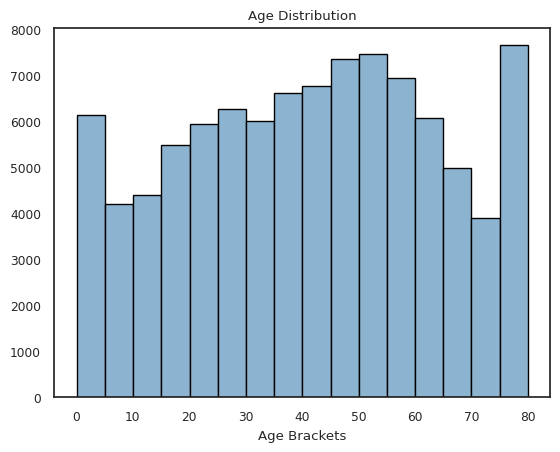

In [48]:
plt.hist(df['age'], bins=16, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age Brackets')
plt.show()

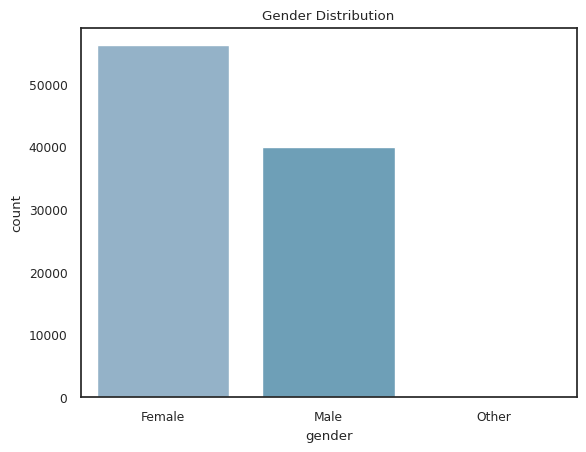

In [49]:
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

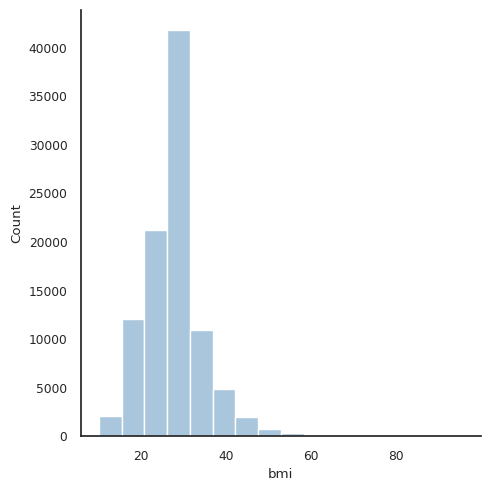

In [50]:
sns.displot(x = 'bmi', data=df, bins=16)

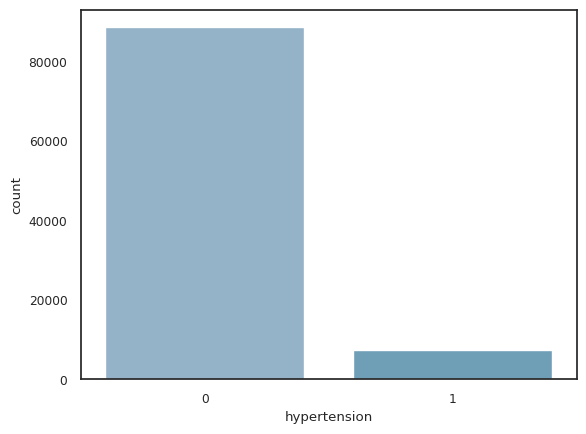

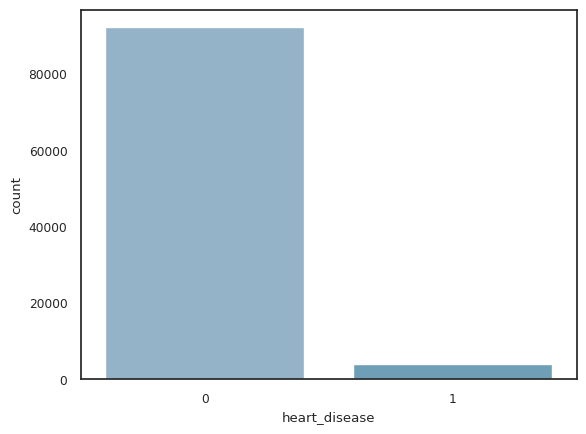

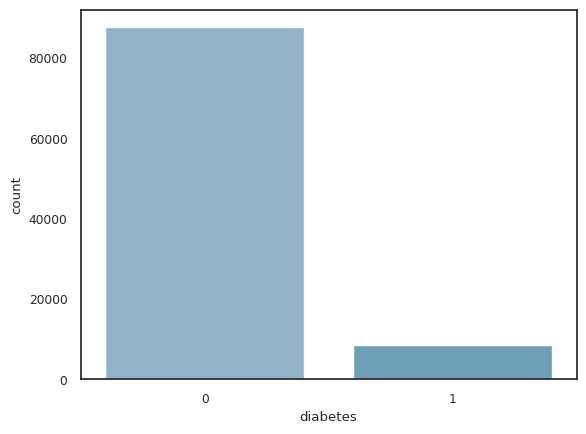

In [51]:
for col in ['hypertension', 'heart_disease', 'diabetes']:
   sns.countplot(x=col, data =df)
   plt.show()

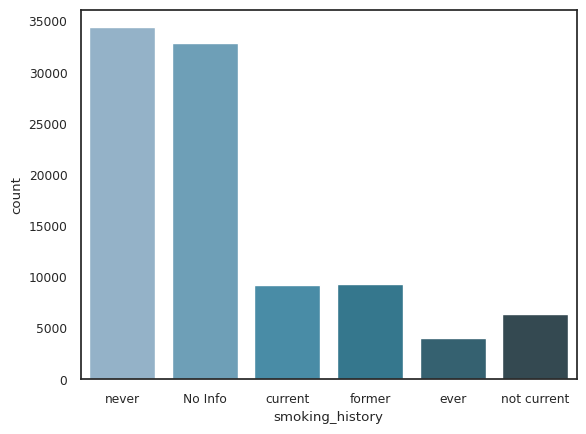

In [52]:
sns.countplot(x='smoking_history', data=df)
plt.show()

# Bivariate Analysis

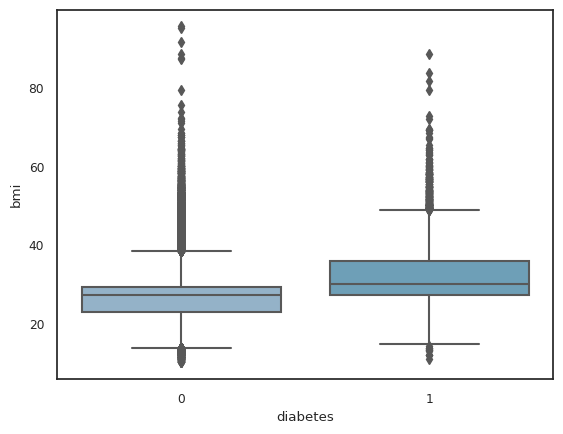

In [53]:
sns.boxplot(x ='diabetes', y='bmi', data=df)
plt.show()

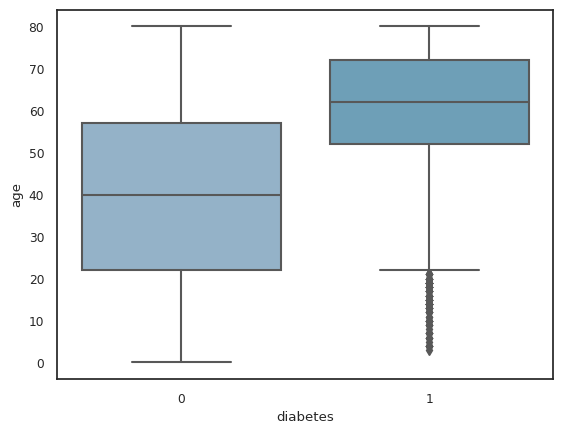

In [54]:
sns.boxplot(x='diabetes', y='age', data=df)
plt.show()

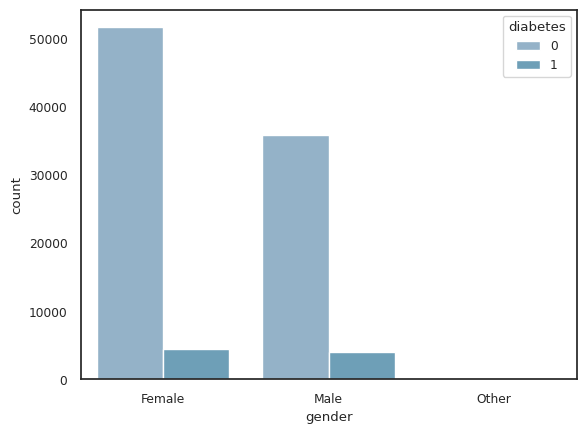

In [55]:
sns.countplot(x = 'gender', hue  = 'diabetes', data=df)
plt.show()

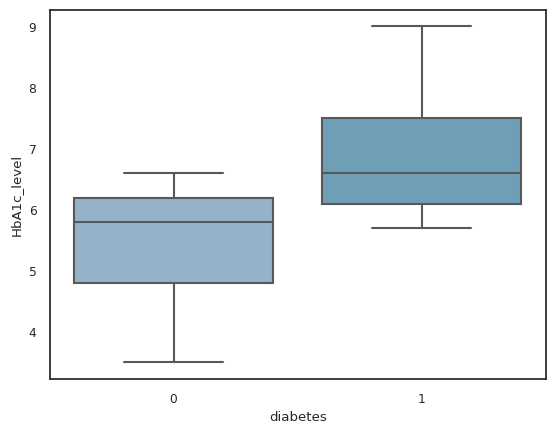

In [56]:
sns.boxplot(x ='diabetes', y= 'HbA1c_level', data=df)
plt.show()

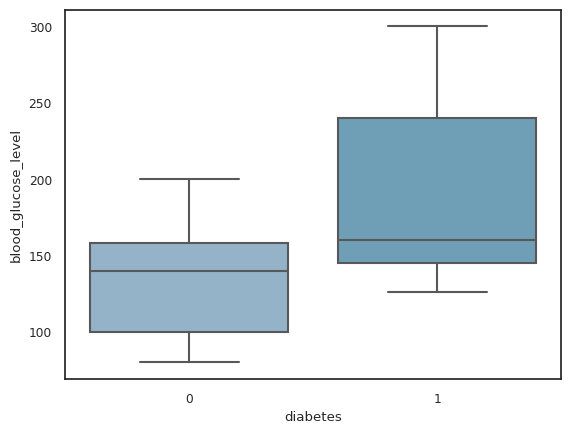

In [57]:
sns.boxplot(x = 'diabetes', y= 'blood_glucose_level', data =df)
plt.show()

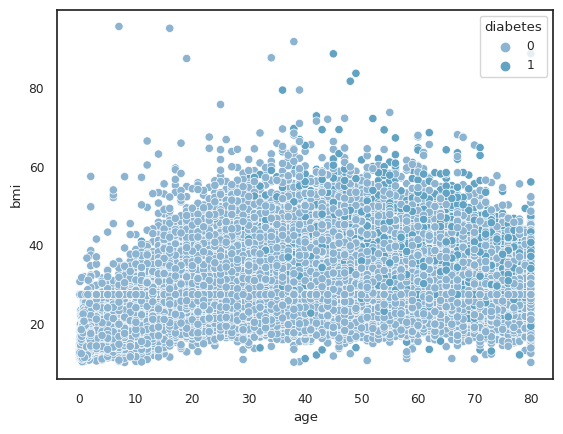

In [58]:
sns.scatterplot(x='age', y='bmi', hue ='diabetes', data=df)
plt.show()

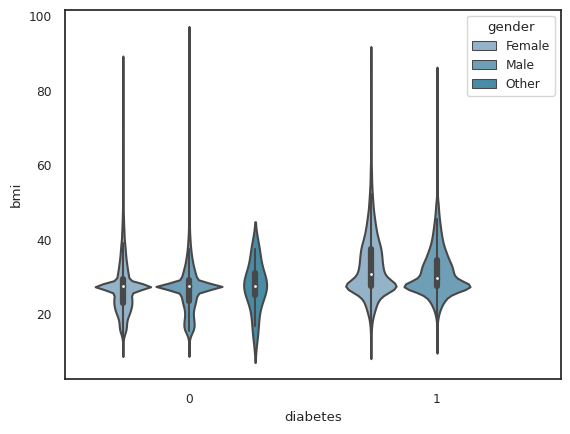

In [59]:
sns.violinplot(x= 'diabetes', y='bmi', hue="gender",  data=df)
plt.show()

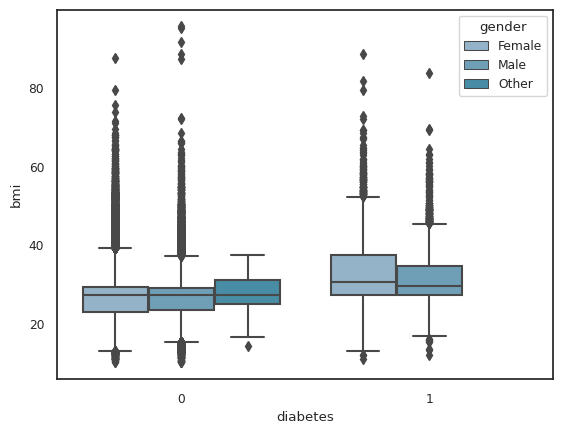

In [60]:
sns.boxplot(x='diabetes', y='bmi', hue='gender', data=df)
plt.show()

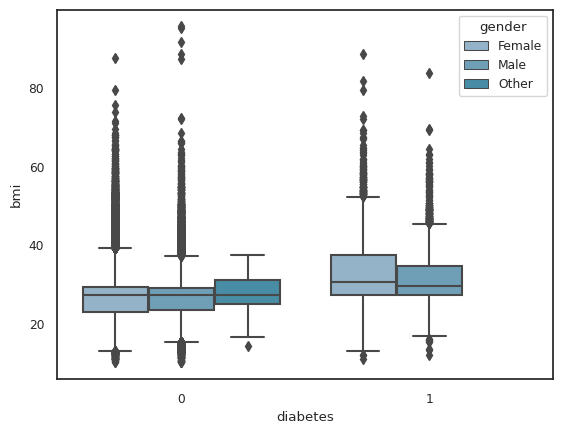

In [61]:
sns.boxplot(x= 'diabetes', y='bmi', hue='gender', data=df)
plt.show()

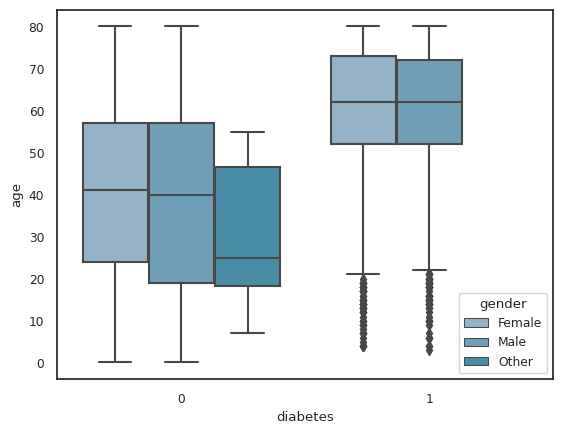

In [62]:
sns.boxplot(x='diabetes', y='age', hue='gender', data=df)
plt.show()

In [63]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [64]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [65]:
def recategorize_smoking(smoking_history_val):
    if smoking_history_val in ['never', 'No Info']:
        return 'non_smoker'
    elif smoking_history_val in ['current']:
        return 'current'
    elif smoking_history_val in ['former', 'ever', 'not current']:
        return 'past_smoker'
    
df['smoking_history'] = df['smoking_history'].apply(recategorize_smoking)
    

In [66]:
print(df['smoking_history'].value_counts())

smoking_history
non_smoker     67285
past_smoker    19664
current         9197
Name: count, dtype: int64


In [67]:
data = df.copy()

In [68]:
def one_hot_encode_dataframe(df, columns_to_encode):
    
    df_encoded = pd.get_dummies(df, columns=columns_to_encode)
    return df_encoded

columns_to_encode = ['gender', 'smoking_history']

encoded_df = one_hot_encode_dataframe(df, columns_to_encode)

# Display the encoded DataFrame
print(encoded_df)


        age  hypertension  heart_disease   bmi  HbA1c_level  \
0     80.00             0              1 25.19         6.60   
1     54.00             0              0 27.32         6.60   
2     28.00             0              0 27.32         5.70   
3     36.00             0              0 23.45         5.00   
4     76.00             1              1 20.14         4.80   
...     ...           ...            ...   ...          ...   
99994 36.00             0              0 24.60         4.80   
99996  2.00             0              0 17.37         6.50   
99997 66.00             0              0 27.83         5.70   
99998 24.00             0              0 35.42         4.00   
99999 57.00             0              0 22.43         6.60   

       blood_glucose_level  diabetes  gender_Female  gender_Male  \
0                      140         0           True        False   
1                       80         0           True        False   
2                      158         0   

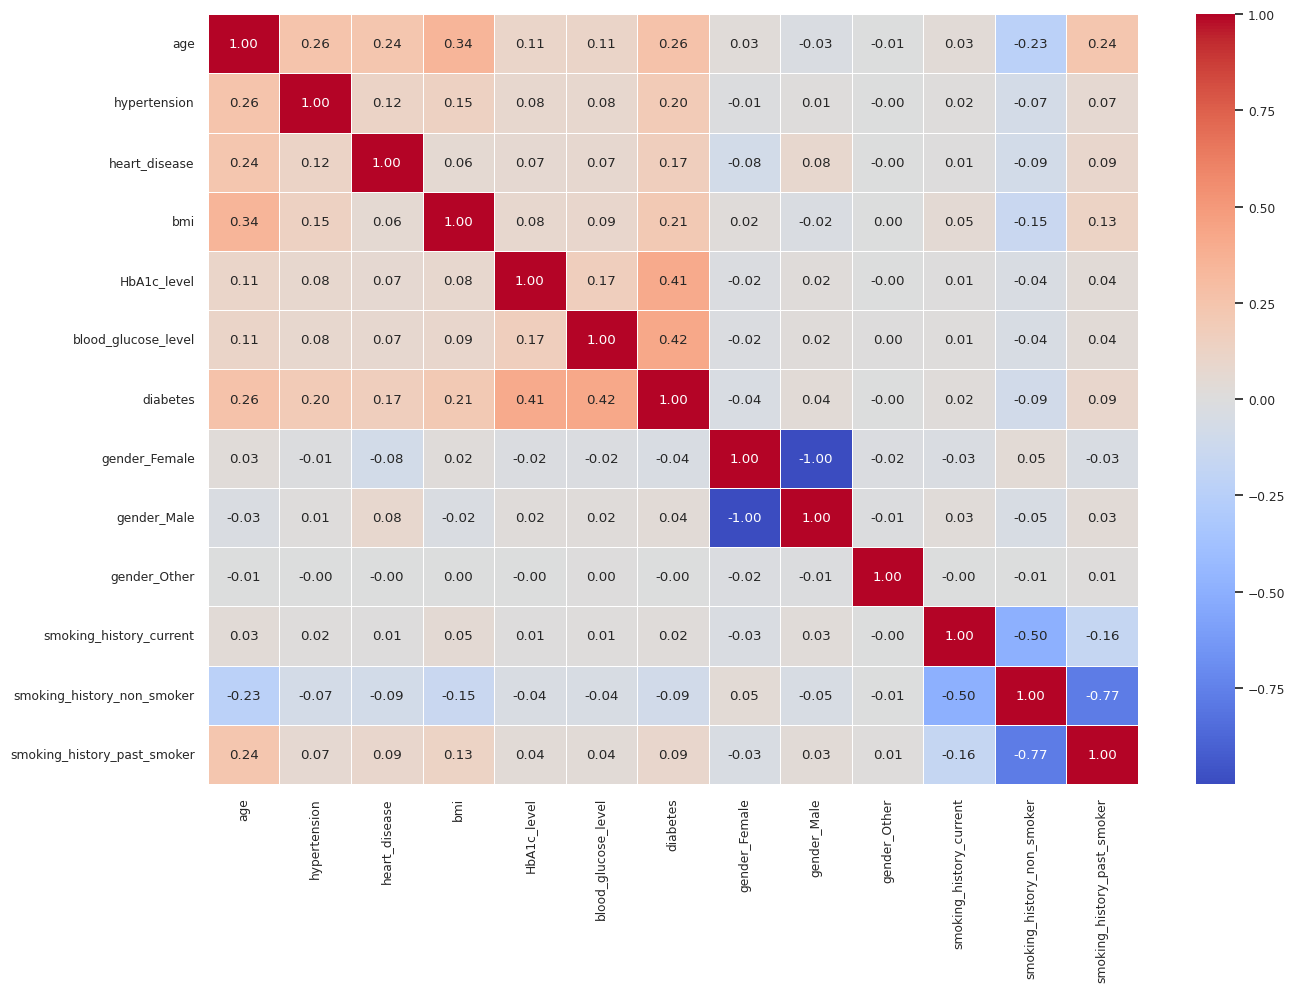

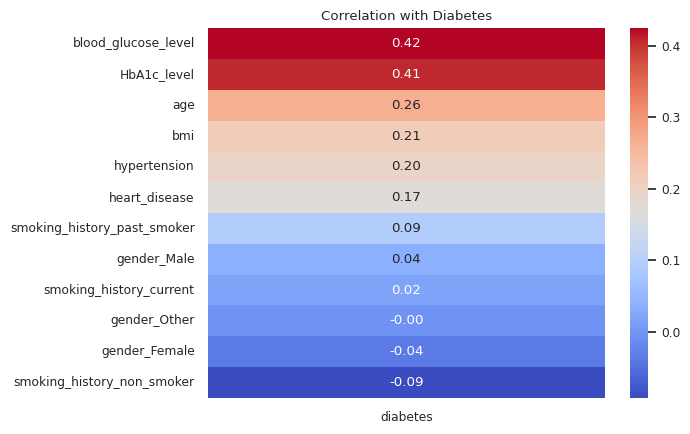

In [69]:
correlation_matrix = encoded_df.corr()

plt.figure(figsize = (15,10))
sns.heatmap(correlation_matrix, annot=True, cmap = 'coolwarm', linewidths = 0.5, fmt = '.2f')
plt.show()

corr = encoded_df.corr()
target_corr = corr['diabetes'].drop('diabetes')
target_corr_sorted = target_corr.sort_values(ascending=False)
sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted.to_frame(), cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation with Diabetes')
plt.show()

# Bias and SMOTE

<Axes: xlabel='diabetes', ylabel='count'>

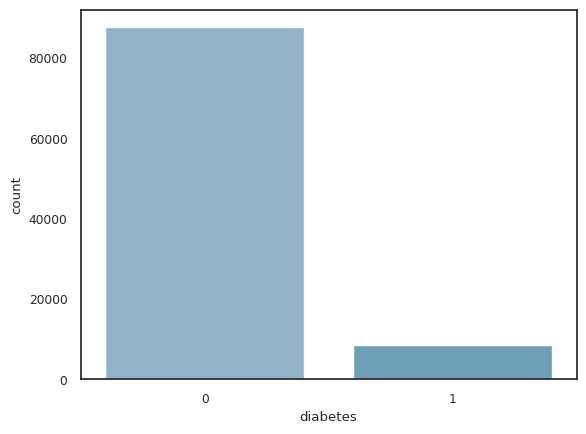

In [70]:
sns.countplot(x='diabetes', data=df)

In [71]:
over= SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)

In [72]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease']),
    ('cat', OneHotEncoder(), ['gender','smoking_history'])
])

X = df.drop('diabetes', axis=1)
y= df['diabetes']

In [73]:
clf = imbPipeline(steps = [('preprocessor',preprocessor ),('over', over),('under', under),('classifier', RandomForestClassifier())])

# Hyperparameter Tuning

In [74]:
parameters= {
    'classifier__n_estimators':[50,100,200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split':[2,5,10],
    'classifier__min_samples_leaf':[1,2,4]
}

In [75]:
grid_search = GridSearchCV(clf, parameters, cv=5)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size =0.2)
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}


0.9512220488819553
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     17509
           1       0.70      0.80      0.75      1721

    accuracy                           0.95     19230
   macro avg       0.84      0.88      0.86     19230
weighted avg       0.96      0.95      0.95     19230



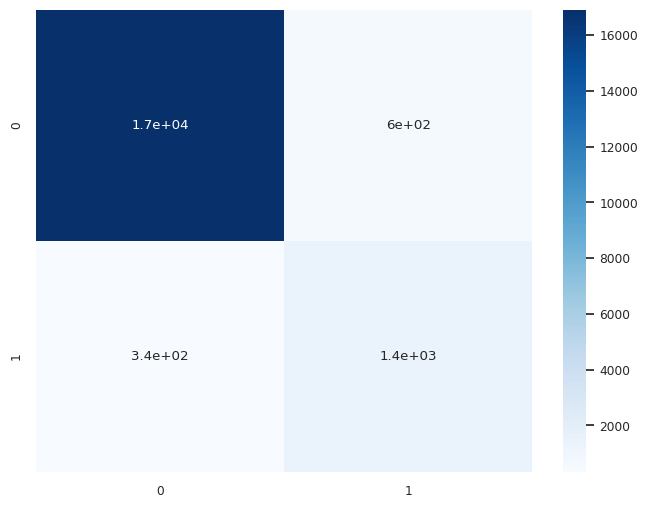

In [77]:
y_pred = grid_search.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap = 'Blues')
plt.show()

# Class 0 (Non- Diabetic):
The model has a high precision (0.98) for class 0, meaning that among all instances where the model predicted non-diabetes, 98% were indeed non-diabetes.
The recall for class 0 is also high (0.96). This means that our model correctly identified 96% of all actual non-diabetes cases in the dataset.

# Class 1 (Diabetic):
The precision for class 1 is lower around (0.65), which indicates that when the model predicted diabetes, it was correct around 65% of the time.
However, the recall is reasonably high around (0.80). This means that our model was able to capture around 80% of all actual diabetes cases.

# Feature Importance

                        Feature  Importance
2                   HbA1c_level        0.44
3           blood_glucose_level        0.32
0                           age        0.13
1                           BMI        0.06
4                  hypertension        0.03
5                 heart_disease        0.02
11  smoking_history_past_smoker        0.00
10   smoking_history_non_smoker        0.00
7                   gender_Male        0.00
6                 gender_Female        0.00
9       smoking_history_current        0.00
8                  gender_Other        0.00


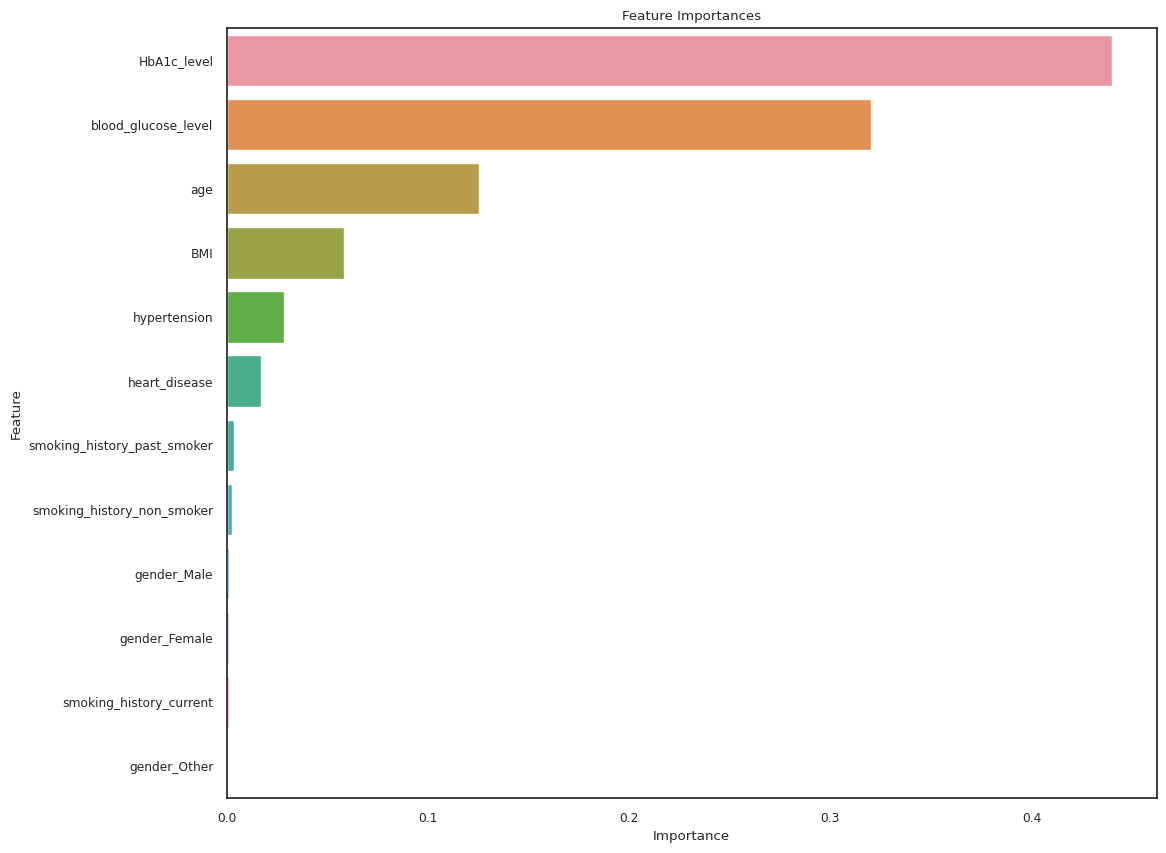

In [78]:
onehot_columns = list(grid_search.best_estimator_.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['gender', 'smoking_history']))

feature_names = ['age', 'BMI', 'HbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease'] + onehot_columns

importances = grid_search.best_estimator_.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature':feature_names, 'Importance': importances})

importance_df = importance_df.sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(12,10))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

# Here are the key findings from the feature importance results:
HbA1c_level is the most important feature with an importance of 0.44. HbA1c is a measure of the average levels of blood glucose over the past 2 to 3 months, so it's not surprising that it's a significant predictor of diabetes.

The blood_glucose_level the second most important feature with an importance of 0.32. This aligns with medical knowledge, as blood glucose levels are directly used to diagnose diabetes.

Age the third most important feature with an importance of 0.14. It's well known that the risk of type 2 diabetes increases as you get older.

BMI comes fourth in terms of importance at 0.06. Body Mass Index is a key risk factor for diabetes, and its role is well documented in medical literature.

Other features like hypertension and heart_disease show some importance (0.02 and 0.01, respectively), indicating that these health conditions might have some relevance in predicting diabetes, though not as significant as the top four factors.

Smoking history ('smoking_history_non-smoker', 'smoking_history_past_smoker', 'smoking_history_current') and gender ('gender_Female', 'gender_Male') are shown to have minimal or zero importance in our model. This could be due to a number of reasons including that these factors may not be as influential in the development of diabetes or it could be a result of how the data was collected or structured.